# A Physics-Informed Neural Network, End to End

## Damped harmonic oscillator

An in-class worked example. We train a small network to satisfy a differential equation rather than to fit data, then check what it actually learned — against the analytic solution, and against the equation itself.

Remember - physics is a part of LOSS here.

## The problem

$$
\frac{d^2x}{dt^2} + 2\gamma \frac{dx}{dt} + \omega_0^2 x = 0,
\qquad
x(0)=x_0,
\qquad
\frac{dx}{dt}(0)=v_0.
$$

Underdamped, $\gamma < \omega_0$, so there is an analytic solution to compare against:

$$
x(t) = e^{-\gamma t}\left[x_0\cos(\omega_d t) + \frac{v_0 + \gamma x_0}{\omega_d}\sin(\omega_d t)\right],
\qquad
\omega_d = \sqrt{\omega_0^2 - \gamma^2}.
$$

The network $x_\theta(t)$ never sees that solution during physics training. It is shown the equation and the two initial conditions, and nothing else.

#### We can't overemphasize this last part! This is not supervised learning! We are only solving this one problem! 

In [1]:
# Imports
import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## 1.1 Problem parameters

An underdamped oscillator. These are the quickest values to change on the spot to see how training responds.

In [2]:
# Physical parameters
omega_0 = 2.0   # natural angular frequency
gamma = 0.25    # damping coefficient; underdamped when gamma < omega_0
x0 = 1.0        # initial displacement
v0 = 0.0        # initial velocity

# Time domain
t_min = 0.0
t_max = 10.0

assert gamma < omega_0, "This analytic solution assumes the underdamped case."


## 1.2 Analytic reference solution

The PINN will not need this solution during physics-based training. We use it for plotting and validation.

How would you use this solution to approach the problem in a fully supervised way? 


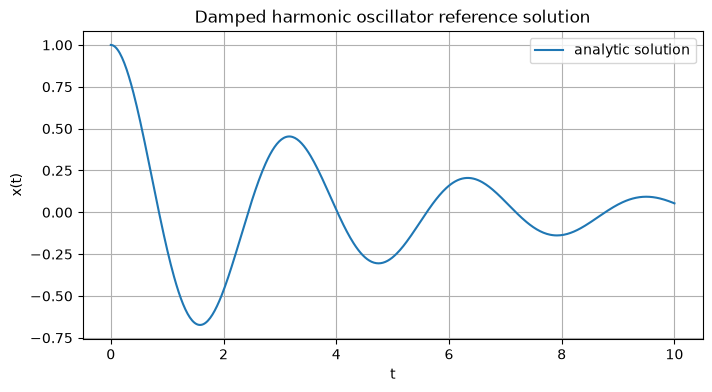

In [4]:
def analytic_solution(t, omega_0=omega_0, gamma=gamma, x0=x0, v0=v0):
    """Analytic solution for an underdamped harmonic oscillator."""
    omega_d = torch.sqrt(torch.tensor(omega_0**2 - gamma**2, dtype=t.dtype, device=t.device))
    return torch.exp(-gamma * t) * (
        x0 * torch.cos(omega_d * t)
        + ((v0 + gamma * x0) / omega_d) * torch.sin(omega_d * t)
    )

# Plot reference solution
with torch.no_grad():
    t_plot = torch.linspace(t_min, t_max, 500, device=DEVICE).view(-1, 1)
    x_ref = analytic_solution(t_plot)

plt.figure(figsize=(8, 4))
plt.plot(t_plot.cpu(), x_ref.cpu(), label="analytic solution")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Damped harmonic oscillator reference solution")
plt.legend()
plt.grid(True)
plt.show()


## 1.3 Collocation points and optional data points

A PINN enforces the governing equation at a set of points in the domain. These are called **collocation points**, this is where your "equation loss" is evaluated.

(We also generate a small set of noisy observations. They are switched off by default (their loss weight is zero) and exist so the same notebook can show a PINN trained purely on physics and one trained on physics plus data. This latter part can also be used for *inversion*)

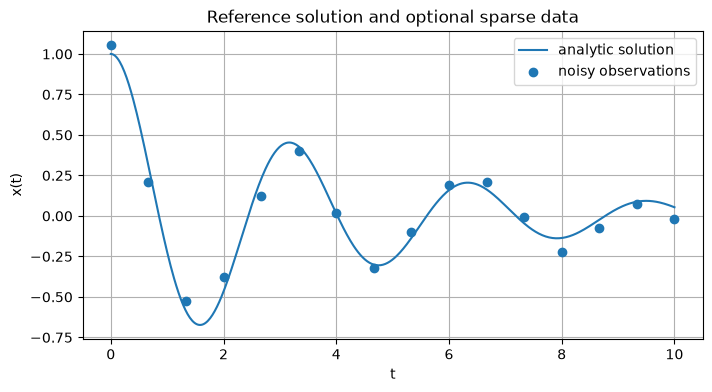

In [5]:
def make_collocation_points(n_points, t_min=t_min, t_max=t_max, device=DEVICE):
    """Uniform random collocation points in the time domain."""
    t = t_min + (t_max - t_min) * torch.rand(n_points, 1, device=device)
    t.requires_grad_(True)
    return t

# Physics collocation points
n_collocation = 200

t_collocation = make_collocation_points(n_collocation)

# Optional sparse observations
n_data = 16
noise_std = 0.05

t_data = torch.linspace(t_min, t_max, n_data, device=DEVICE).view(-1, 1)
with torch.no_grad():
    x_data_clean = analytic_solution(t_data)
    x_data = x_data_clean + noise_std * torch.randn_like(x_data_clean)

plt.figure(figsize=(8, 4))
plt.plot(t_plot.cpu(), x_ref.cpu(), label="analytic solution")
plt.scatter(t_data.cpu(), x_data.cpu(), label="noisy observations", zorder=3)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Reference solution and optional sparse data")
plt.legend()
plt.grid(True)
plt.show()


## 1.4 Define the neural network

The network maps a scalar input $t$ to a scalar output $x_\theta(t)$. For this smooth ODE, a multilayer perceptron with `tanh` activations is a reasonable starting point. 

We use `tanh` because a second derivative appears (`ReLU` would give zero).

The "hyperparameters" of our problem are:

Depth, width, activation, and the input normalization. (We can change of all them later) 

Note that the initial conditions are enforced *softly* here, through a loss term, rather than being built into the model.

In [6]:
class MLP(nn.Module):
    """Simple fully connected neural network for scalar input and scalar output."""

    def __init__(self, in_dim=1, out_dim=1, hidden_dim=64, n_hidden_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # Normalize t from [t_min, t_max] to approximately [-1, 1]
        t_scaled = 2.0 * (t - t_min) / (t_max - t_min) - 1.0
        return self.net(t_scaled)

model = MLP(hidden_dim=64, n_hidden_layers=3).to(DEVICE)
print(model)


MLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


#### *Can you calculate how "complex" the model is in terms of the number of parameters?*

## 1.5 Automatic differentiation for derivatives

The physics residual requires first and second derivatives with respect to time. PyTorch can compute these using automatic differentiation.


In [8]:
def gradients(y, x):
    """Compute dy/dx for scalar-output tensors using autograd."""
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def oscillator_residual(model, t):
    """Compute residual r(t) = x_tt + 2 gamma x_t + omega_0^2 x."""
    x_pred = model(t)
    x_t = gradients(x_pred, t)
    x_tt = gradients(x_t, t)
    residual = x_tt + 2.0 * gamma * x_t + omega_0**2 * x_pred
    return residual


## 1.6 Loss terms

We combine three possible losses:

1. **Physics loss**: the ODE residual should be close to zero.
2. **Initial-condition loss**: the predicted position and velocity at $t=0$ should match $x_0$ and $v_0$.
3. **Data loss**: optional fit to sparse observations.

$$
\mathcal{L} = \lambda_{phys}\mathcal{L}_{phys}
+ \lambda_{ic}\mathcal{L}_{ic}
+ \lambda_{data}\mathcal{L}_{data}.
$$

The weighting coefficients are important!


In [9]:
mse = nn.MSELoss()

loss_weights = {
    "physics": 1.0,
    "initial_condition": 10.0,
    "data": 0.0,  # for the moment we don't want it. 
}


def compute_losses(model, t_collocation, t_data=None, x_data=None):
    
    """Return individual PINN loss terms."""
    # Physics residual loss
    r = oscillator_residual(model, t_collocation)
    loss_physics = mse(r, torch.zeros_like(r))

    # Initial condition loss at t = 0
    t0_tensor = torch.tensor([[t_min]], dtype=torch.float32, device=DEVICE, requires_grad=True)
    x0_pred = model(t0_tensor)
    v0_pred = gradients(x0_pred, t0_tensor)

    loss_ic_x = mse(x0_pred, torch.tensor([[x0]], dtype=torch.float32, device=DEVICE))
    loss_ic_v = mse(v0_pred, torch.tensor([[v0]], dtype=torch.float32, device=DEVICE))
    loss_ic = loss_ic_x + loss_ic_v

    # Optional data loss
    if t_data is not None and x_data is not None:
        x_pred_data = model(t_data)
        loss_data = mse(x_pred_data, x_data)
    else:
        loss_data = torch.tensor(0.0, device=DEVICE)

    return {
        "physics": loss_physics,
        "initial_condition": loss_ic,
        "data": loss_data,
    }


def total_loss(loss_dict, weights=loss_weights):
    return sum(weights[name] * value for name, value in loss_dict.items())


## 1.7 Training loop

This loop uses Adam. For many PINN problems, a common strategy is to train first with Adam and then refine with L-BFGS, or something else. Adam alone is enough for this introductory example.


In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

n_epochs = 15000
print_every = 500

history = {
    "total": [],
    "physics": [],
    "initial_condition": [],
    "data": [],
}

for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()

    # Resample collocation points periodically to reduce overfitting to a fixed set
    if epoch == 1 or epoch % 100 == 0:
        t_collocation = make_collocation_points(n_collocation)

    losses = compute_losses(model, t_collocation, t_data=t_data, x_data=x_data)
    loss = total_loss(losses)
    loss.backward()
    optimizer.step()

    history["total"].append(loss.item())
    for key in ["physics", "initial_condition", "data"]:
        history[key].append(losses[key].item())

    if epoch % print_every == 0 or epoch == 1:
        print(
            f"epoch {epoch:5d} | "
            f"total={history['total'][-1]:.3e} | "
            f"phys={history['physics'][-1]:.3e} | "
            f"ic={history['initial_condition'][-1]:.3e} | "
            f"data={history['data'][-1]:.3e}"
        )


epoch     1 | total=1.086e+01 | phys=1.273e-01 | ic=1.073e+00 | data=1.343e-01
epoch   500 | total=2.224e+00 | phys=1.282e+00 | ic=9.413e-02 | data=1.489e-01
epoch  1000 | total=1.460e+00 | phys=9.398e-01 | ic=5.204e-02 | data=1.365e-01
epoch  1500 | total=4.634e-01 | phys=3.791e-01 | ic=8.422e-03 | data=7.669e-02
epoch  2000 | total=2.649e-01 | phys=2.487e-01 | ic=1.620e-03 | data=4.481e-02
epoch  2500 | total=1.438e-01 | phys=1.406e-01 | ic=3.171e-04 | data=3.619e-02
epoch  3000 | total=1.136e-01 | phys=1.115e-01 | ic=2.119e-04 | data=3.149e-02
epoch  3500 | total=8.708e-02 | phys=8.618e-02 | ic=8.964e-05 | data=2.915e-02
epoch  4000 | total=6.361e-02 | phys=6.315e-02 | ic=4.679e-05 | data=2.478e-02
epoch  4500 | total=5.371e-02 | phys=5.348e-02 | ic=2.281e-05 | data=2.326e-02
epoch  5000 | total=3.691e-02 | phys=3.671e-02 | ic=1.998e-05 | data=1.880e-02
epoch  5500 | total=2.435e-02 | phys=2.424e-02 | ic=1.107e-05 | data=1.409e-02
epoch  6000 | total=1.639e-02 | phys=1.634e-02 | ic=

## 1.8 Inspect training history

Each loss term gets its own panel. Plotted together on one axis they span several orders of magnitude, and whichever term happens to be largest visually swamps the rest — the shape of the small terms is exactly what you want to see. Note that the vertical scales below are independent.

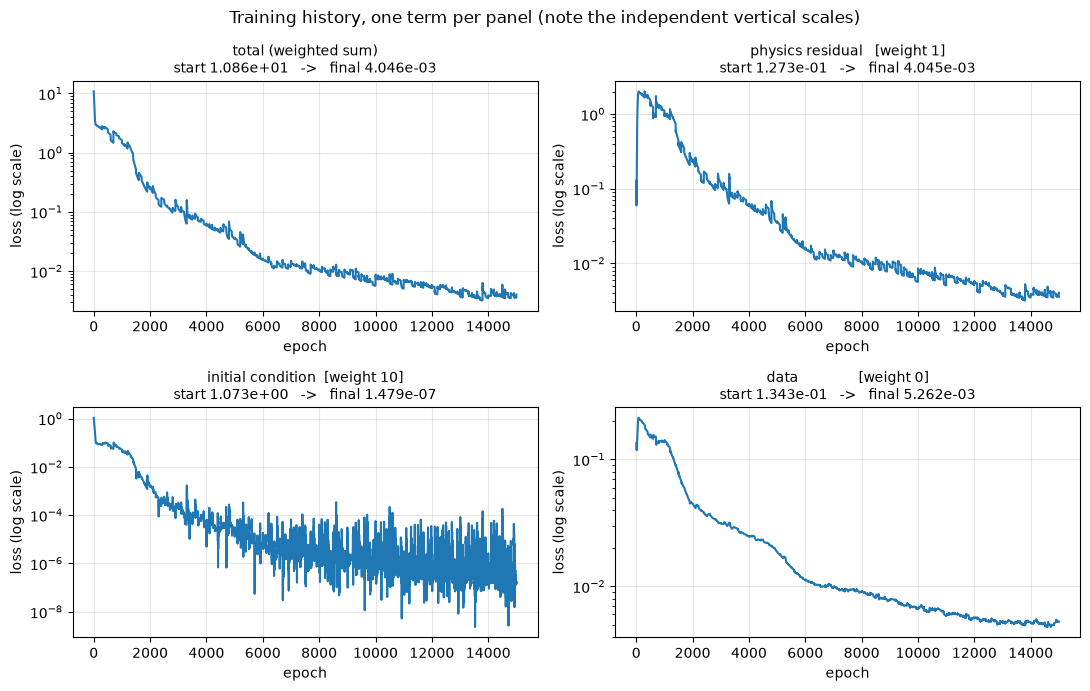

In [11]:
panels = [
    ("total", f"total (weighted sum)"),
    ("physics", f"physics residual   [weight {loss_weights['physics']:g}]"),
    ("initial_condition", f"initial condition  [weight {loss_weights['initial_condition']:g}]"),
    ("data", f"data               [weight {loss_weights['data']:g}]"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, (key, title) in zip(axes.flat, panels):
    values = np.asarray(history[key])
    if np.all(values > 0):
        ax.semilogy(values)
        ax.set_ylabel("loss (log scale)")
    else:
        # A term switched off entirely sits at exactly zero; log axes cannot show it.
        ax.plot(values)
        ax.set_ylabel("loss (linear scale)")
    ax.set_title(f"{title}\nstart {values[0]:.3e}   ->   final {values[-1]:.3e}", fontsize=10)
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)

fig.suptitle("Training history, one term per panel (note the independent vertical scales)")
fig.tight_layout()
plt.show()

## 1.9 Compare the PINN solution with the analytic solution

The following plot compares the trained model against the analytic solution and the optional training observations.


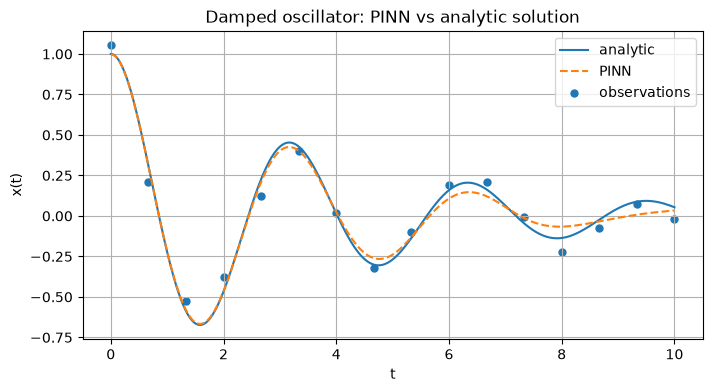

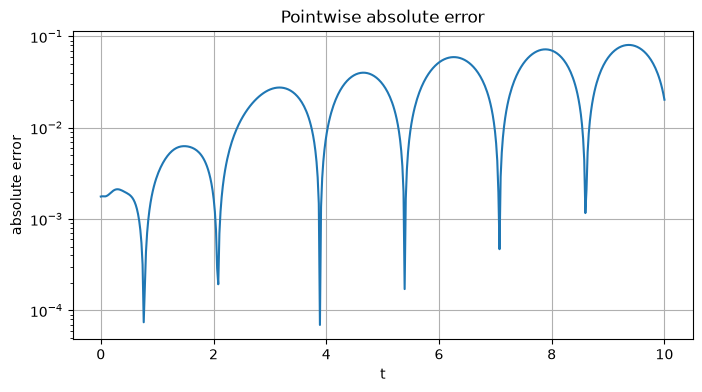

Mean absolute error: 2.829e-02
Max absolute error:  8.055e-02


In [12]:
model.eval()
with torch.no_grad():
    x_pinn = model(t_plot)
    x_true = analytic_solution(t_plot)
    abs_error = torch.abs(x_pinn - x_true)

plt.figure(figsize=(8, 4))
plt.plot(t_plot.cpu(), x_true.cpu(), label="analytic")
plt.plot(t_plot.cpu(), x_pinn.cpu(), "--", label="PINN")
plt.scatter(t_data.cpu(), x_data.cpu(), s=25, label="observations")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Damped oscillator: PINN vs analytic solution")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogy(t_plot.cpu(), abs_error.cpu())
plt.xlabel("t")
plt.ylabel("absolute error")
plt.title("Pointwise absolute error")
plt.grid(True)
plt.show()

print(f"Mean absolute error: {abs_error.mean().item():.3e}")
print(f"Max absolute error:  {abs_error.max().item():.3e}")


## 1.10 Check the learned physics residual

A model can visually match the solution while still violating the differential equation in parts of the domain. Always inspect the residual.


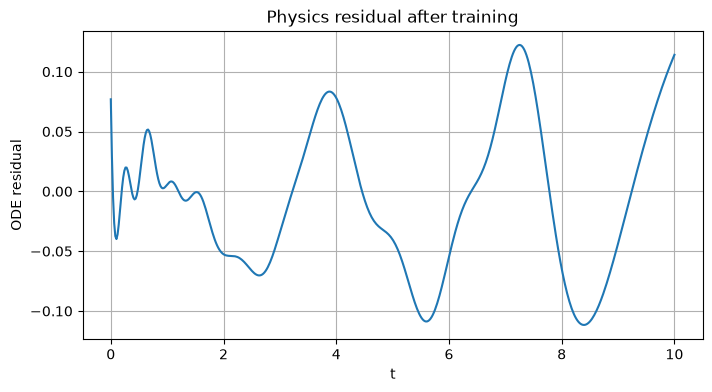

RMS residual: 6.141e-02


In [13]:
t_res = torch.linspace(t_min, t_max, 500, device=DEVICE).view(-1, 1)
t_res.requires_grad_(True)
r_res = oscillator_residual(model, t_res)

plt.figure(figsize=(8, 4))
plt.plot(t_res.detach().cpu(), r_res.detach().cpu())
plt.xlabel("t")
plt.ylabel("ODE residual")
plt.title("Physics residual after training")
plt.grid(True)
plt.show()

print(f"RMS residual: {torch.sqrt(torch.mean(r_res**2)).item():.3e}")
